In [1]:
pip install textblob nltk plotly

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 996.2 kB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
# Loading Datasets
df_apps = pd.read_csv('googleplaystore.csv')
df_reviews = pd.read_csv('googleplaystore_user_reviews.csv')

In [4]:
#  Structural Overview
print("=== GOOGLE PLAY STORE APPS OVERVIEW ===")
print(f"Apps Shape: {df_apps.shape[0]} rows | {df_apps.shape[1]} columns")
print(f"App Duplicates: {df_apps.duplicated(subset=['App']).sum()}")
print(f"Apps Missing Values:\n{df_apps.isnull().sum()[df_apps.isnull().sum() > 0]}\n")

print("=== USER REVIEWS OVERVIEW ===")
print(f"Reviews Shape: {df_reviews.shape[0]} rows | {df_reviews.shape[1]} columns")
print(f"Reviews Missing Values:\n{df_reviews.isnull().sum()[df_reviews.isnull().sum() > 0]}\n")

# Displaying top 5 rows
display(df_apps.head())

=== GOOGLE PLAY STORE APPS OVERVIEW ===
Apps Shape: 10841 rows | 13 columns
App Duplicates: 1181
Apps Missing Values:
Rating            1474
Type                 1
Content Rating       1
Current Ver          8
Android Ver          3
dtype: int64

=== USER REVIEWS OVERVIEW ===
Reviews Shape: 64295 rows | 5 columns
Reviews Missing Values:
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
# 1. Droping duplicate apps (keep first instance)
df_apps_clean = df_apps.drop_duplicates(subset=['App']).copy()

# 2. Clean 'Installs': Remove '+' and ',', convert to numeric integer
df_apps_clean['Installs'] = df_apps_clean['Installs'].str.replace('+', '', regex=False)
df_apps_clean['Installs'] = df_apps_clean['Installs'].str.replace(',', '', regex=False)
# Remove non-numeric corrupt rows if any exist
df_apps_clean = df_apps_clean[df_apps_clean['Installs'] != 'Free'].copy()
df_apps_clean['Installs'] = df_apps_clean['Installs'].astype(int)

# 3. Clean 'Price': Remove '$', convert to float
df_apps_clean['Price'] = df_apps_clean['Price'].str.replace('$', '', regex=False).astype(float)

# 4. Clean 'Size': Convert 'M' to numeric (MB), 'k' to MB, handle 'Varies with device'
def convert_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', ''))
        elif 'k' in size:
            return float(size.replace('k', '')) / 1024.0
    return np.nan

df_apps_clean['Size_MB'] = df_apps_clean['Size'].apply(convert_size)

# 5. Clean 'Reviews': Convert to integer
df_apps_clean['Reviews'] = df_apps_clean['Reviews'].astype(int)

# 6. Impute missing 'Rating' with median rating by Category
df_apps_clean['Rating'] = df_apps_clean.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))

# Verification Output
print("=== DATA CLEANING PIPELINE SUMMARY ===")
print(f"Cleaned Apps Shape: {df_apps_clean.shape[0]} rows | {df_apps_clean.shape[1]} columns")
print(f"Remaining Missing Values in Rating: {df_apps_clean['Rating'].isnull().sum()}")
print(f"Numeric Installs Range: {df_apps_clean['Installs'].min():,} to {df_apps_clean['Installs'].max():,}")
print(f"Numeric Price Range: ${df_apps_clean['Price'].min()} to ${df_apps_clean['Price'].max()}")

df_apps_clean[['App', 'Category', 'Rating', 'Reviews', 'Size_MB', 'Installs', 'Price']].head()

=== DATA CLEANING PIPELINE SUMMARY ===
Cleaned Apps Shape: 9659 rows | 14 columns
Remaining Missing Values in Rating: 0
Numeric Installs Range: 0 to 1,000,000,000
Numeric Price Range: $0.0 to $400.0


,App,Category,Rating,Reviews,Size_MB,Installs,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,0.0


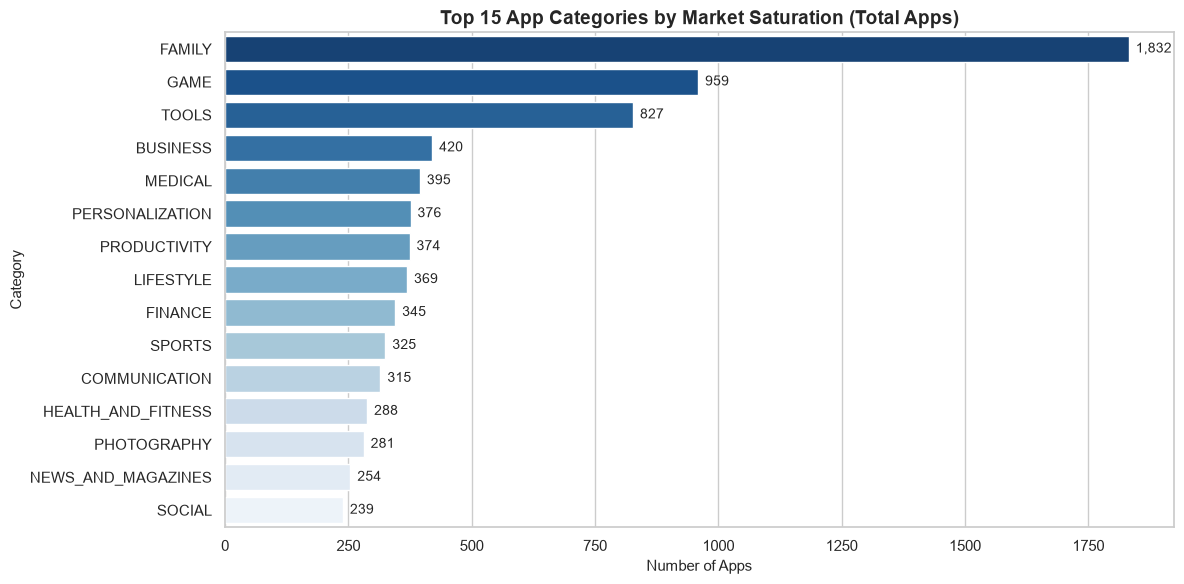

,Category,App Count,Installs,Avg Rating
11,FAMILY,1832,4427941505,4.194378
14,GAME,959,13878924415,4.249948
29,TOOLS,827,8001771915,4.060701
4,BUSINESS,420,697164865,4.136429
20,MEDICAL,395,38193177,4.202025
23,PERSONALIZATION,376,1532494782,4.346277
25,PRODUCTIVITY,374,5793091369,4.206150
18,LIFESTYLE,369,503823539,4.113008
12,FINANCE,345,455348734,4.138551
28,SPORTS,325,1096474498,4.232923


In [6]:
# 1. Aggregating app counts and total installs by category
category_summary = df_apps_clean.groupby('Category').agg({
    'App': 'count',
    'Installs': 'sum',
    'Rating': 'mean'
}).rename(columns={'App': 'App Count', 'Rating': 'Avg Rating'}).reset_index()

# Sort by total app count descending
category_summary = category_summary.sort_values(by='App Count', ascending=False)

# 2. Plot Top 15 Most Saturated App Categories
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=category_summary.head(15),
    x='App Count',
    y='Category',
    hue='Category',
    palette='Blues_r',
    legend=False
)

plt.title('Top 15 App Categories by Market Saturation (Total Apps)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Apps', fontsize=11)
plt.ylabel('Category', fontsize=11)

# Annotate count values on bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width):,}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# Display top 10 categories table
display(category_summary.head(10))

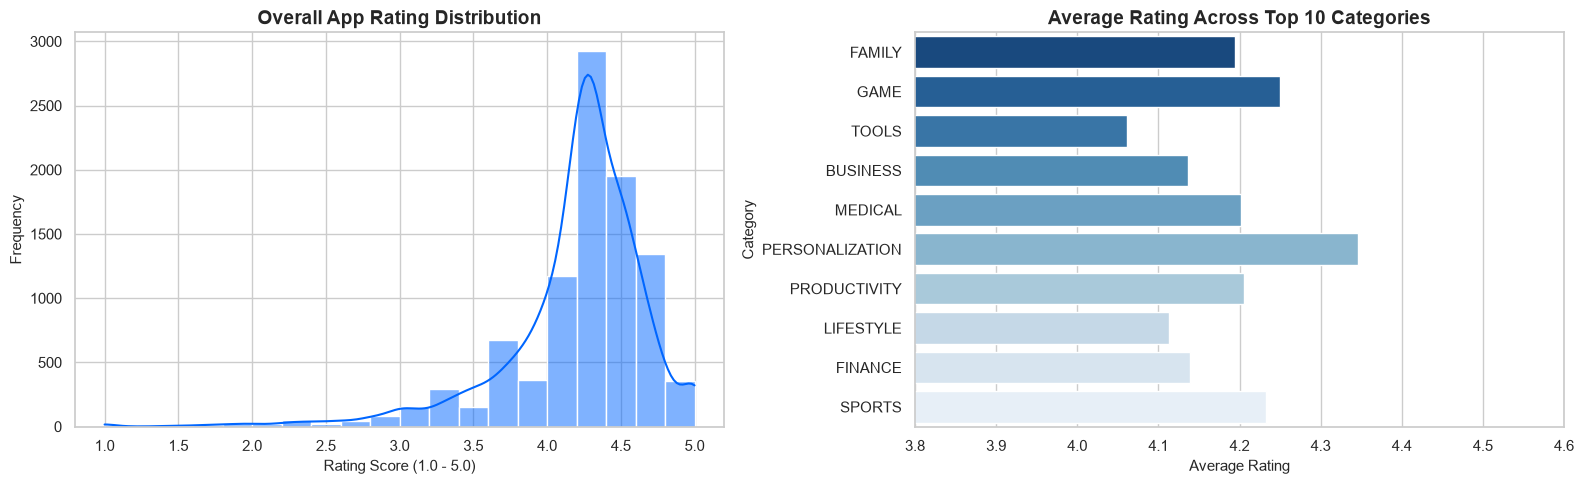

In [7]:
# 1. Setup side-by-side plots for Rating Distribution and Category Ratings
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Overall App Rating Distribution
sns.histplot(df_apps_clean['Rating'], kde=True, ax=axes[0], color='#0066FF', bins=20)
axes[0].set_title('Overall App Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating Score (1.0 - 5.0)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

# Plot 2: Average Rating by Top 10 Saturated Categories
top_cats = category_summary.head(10)
sns.barplot(
    data=top_cats,
    x='Avg Rating',
    y='Category',
    hue='Category',
    ax=axes[1],
    palette='Blues_r',
    legend=False
)
axes[1].set_title('Average Rating Across Top 10 Categories', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Rating', fontsize=11)
axes[1].set_ylabel('Category', fontsize=11)
axes[1].set_xlim(3.8, 4.6) # Focus scale on competitive range

plt.tight_layout()
plt.show()

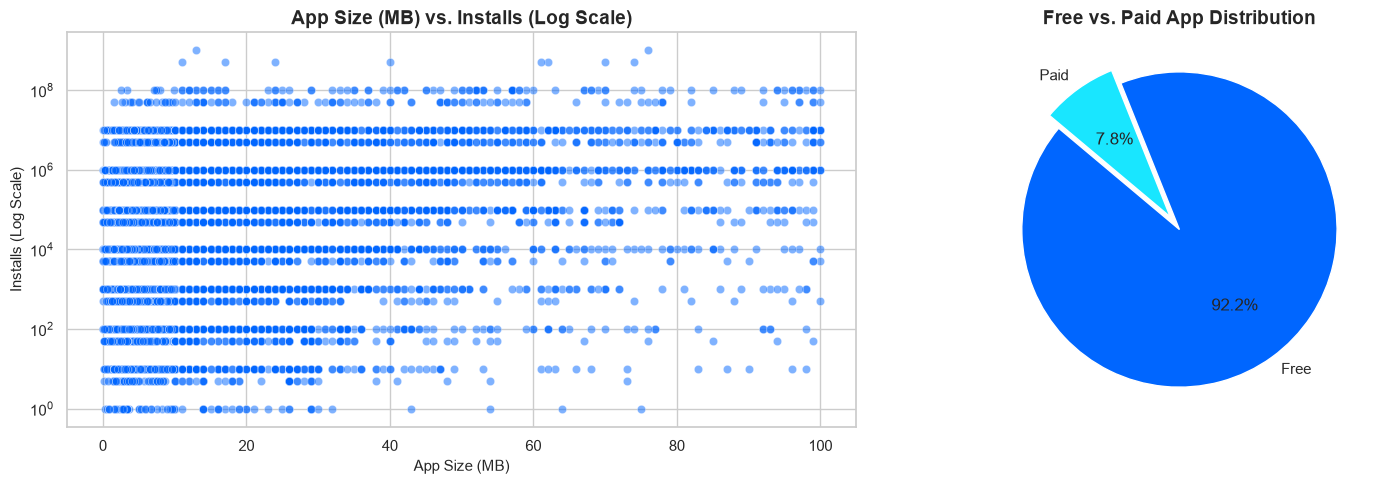

=== PRICING & REVENUE SUMMARY ===
Free Apps: 8,902 (92.2%)
Paid Apps: 756 (7.8%)
Average Paid App Price: $14.05
Median Paid App Price: $2.99


In [8]:
# 1. Setup side-by-side plots for Size vs. Installs and Free vs. Paid breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: App Size vs. Number of Installs (Scatter Plot)
df_size_clean = df_apps_clean.dropna(subset=['Size_MB', 'Installs'])
sns.scatterplot(
    data=df_size_clean,
    x='Size_MB',
    y='Installs',
    alpha=0.5,
    color='#0066FF',
    ax=axes[0]
)
axes[0].set_yscale('log') # Log scale for installs
axes[0].set_title('App Size (MB) vs. Installs (Log Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('App Size (MB)', fontsize=11)
axes[0].set_ylabel('Installs (Log Scale)', fontsize=11)

# Plot 2: Free vs. Paid App Distribution
type_counts = df_apps_clean['Type'].value_counts()
axes[1].pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#0066FF', '#19E6FF'],
    explode=(0, 0.1)
)
axes[1].set_title('Free vs. Paid App Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print Pricing Summary Stats
print("=== PRICING & REVENUE SUMMARY ===")
print(f"Free Apps: {type_counts.get('Free', 0):,} ({type_counts.get('Free', 0)/len(df_apps_clean)*100:.1f}%)")
print(f"Paid Apps: {type_counts.get('Paid', 0):,} ({type_counts.get('Paid', 0)/len(df_apps_clean)*100:.1f}%)")
paid_apps = df_apps_clean[df_apps_clean['Type'] == 'Paid']
print(f"Average Paid App Price: ${paid_apps['Price'].mean():.2f}")
print(f"Median Paid App Price: ${paid_apps['Price'].median():.2f}")

C:\Users\alee_\AppData\Local\Temp\ipykernel_8236\4229747844.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alee_\AppData\Local\Temp\ipykernel_8236\4229747844.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


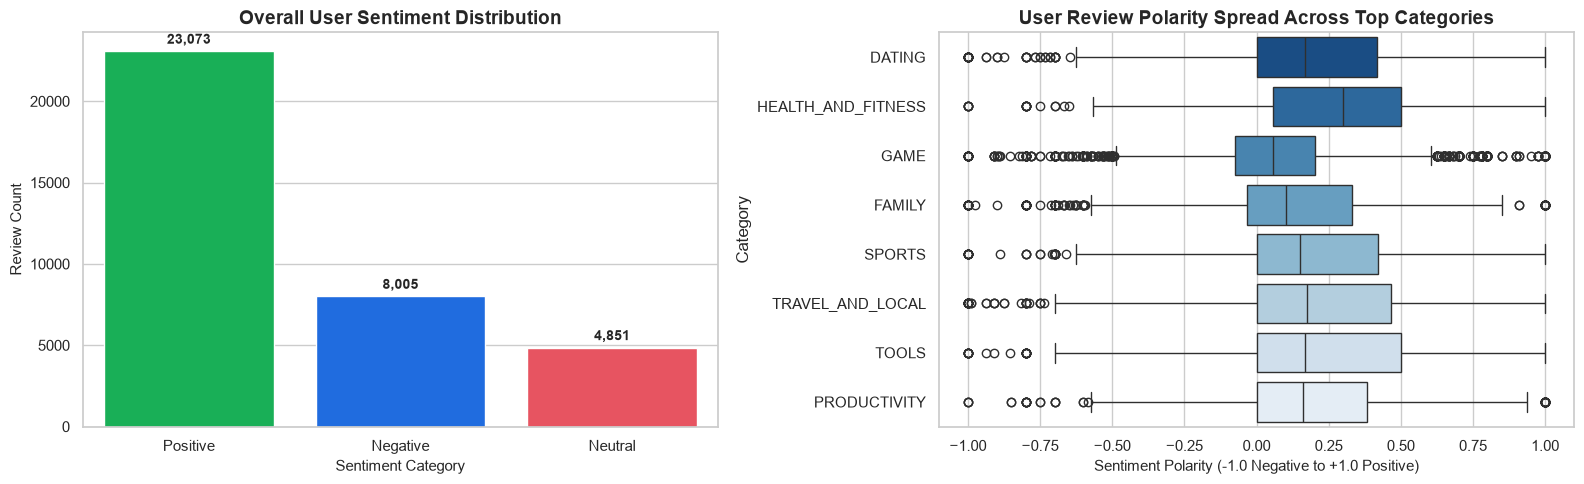

=== SENTIMENT ANALYSIS SUMMARY ===
Total Merged User Reviews: 35,929
Positive Reviews: 23,073 (64.2%)
Negative Reviews: 8,005 (22.3%)
Neutral Reviews: 4,851 (13.5%)


In [9]:
# 1. Clean reviews dataset and merge with apps dataset
df_reviews_clean = df_reviews.dropna(subset=['Translated_Review', 'Sentiment']).copy()

merged_df = pd.merge(
    df_apps_clean, 
    df_reviews_clean, 
    on='App', 
    how='inner'
)

# 2. Setup plots for Sentiment Distribution & Sentiment by Top Categories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Overall Sentiment Breakdown
sentiment_counts = merged_df['Sentiment'].value_counts()
sns.barplot(
    x=sentiment_counts.index, 
    y=sentiment_counts.values, 
    ax=axes[0], 
    palette=['#00C853', '#0066FF', '#FF3B4D']
)
axes[0].set_title('Overall User Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Category', fontsize=11)
axes[0].set_ylabel('Review Count', fontsize=11)

# Annotate counts on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 8), 
                     textcoords='offset points', fontsize=10, fontweight='bold')

# Plot 2: Sentiment Polarity Boxplot across Top 8 Saturated Categories
top_merged_cats = merged_df['Category'].value_counts().head(8).index
df_top_reviews = merged_df[merged_df['Category'].isin(top_merged_cats)]

sns.boxplot(
    data=df_top_reviews,
    x='Sentiment_Polarity',
    y='Category',
    ax=axes[1],
    palette='Blues_r'
)
axes[1].set_title('User Review Polarity Spread Across Top Categories', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment Polarity (-1.0 Negative to +1.0 Positive)', fontsize=11)

plt.tight_layout()
plt.show()

# Print Sentiment Metrics Summary
print("=== SENTIMENT ANALYSIS SUMMARY ===")
print(f"Total Merged User Reviews: {len(merged_df):,}")
print(f"Positive Reviews: {sentiment_counts.get('Positive', 0):,} ({sentiment_counts.get('Positive', 0)/len(merged_df)*100:.1f}%)")
print(f"Negative Reviews: {sentiment_counts.get('Negative', 0):,} ({sentiment_counts.get('Negative', 0)/len(merged_df)*100:.1f}%)")
print(f"Neutral Reviews: {sentiment_counts.get('Neutral', 0):,} ({sentiment_counts.get('Neutral', 0)/len(merged_df)*100:.1f}%)")

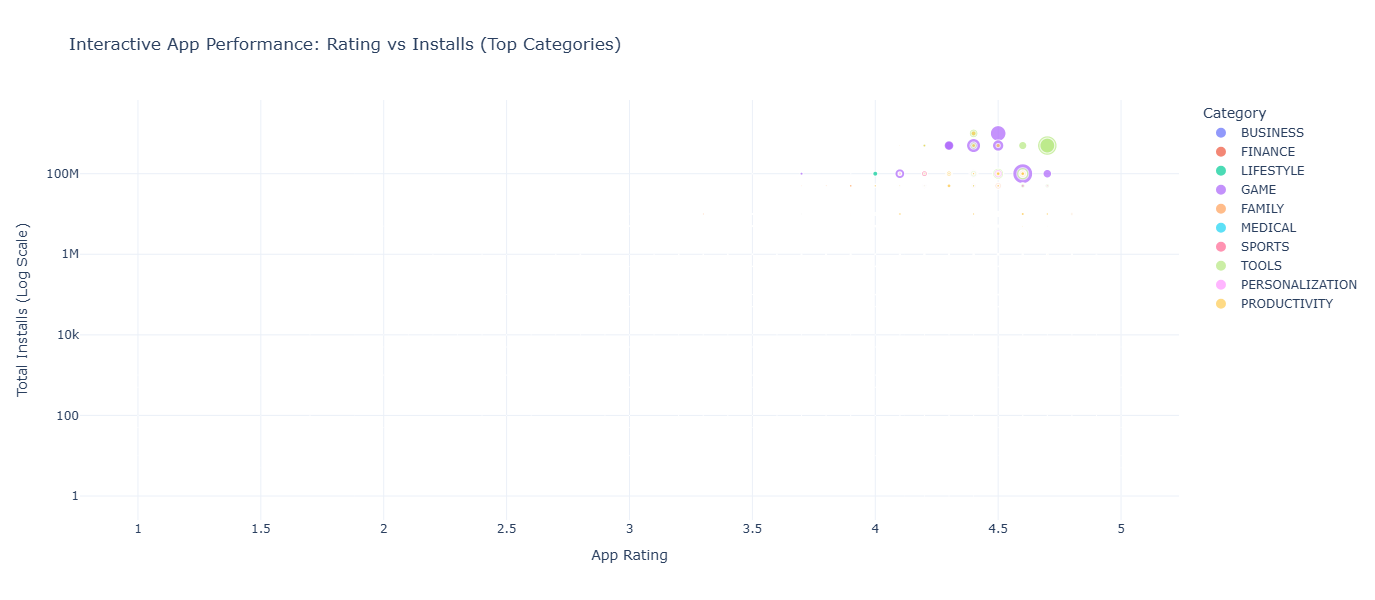

In [10]:
# Create an interactive Plotly scatter plot: Rating vs Installs by Category
top_10_cats = category_summary.head(10)['Category'].tolist()
df_plotly = df_apps_clean[df_apps_clean['Category'].isin(top_10_cats)].dropna(subset=['Rating', 'Installs'])

fig = px.scatter(
    df_plotly,
    x="Rating",
    y="Installs",
    color="Category",
    size="Reviews",
    hover_name="App",
    log_y=True,
    title="Interactive App Performance: Rating vs Installs (Top Categories)",
    labels={"Rating": "App Rating", "Installs": "Total Installs (Log Scale)"},
    template="plotly_white"
)

fig.update_layout(height=600, width=950)
fig.show()

## 📊 Key Findings & Actionable Developer Recommendations

### 1. Key Market Observations
* **Market Saturation:** **Family** (1,832 apps) and **Game** (959 apps) categories are heavily saturated, requiring significantly higher marketing spend to achieve organic visibility.
* **Monetization Dominance:** **92.2%** of store apps are free, indicating that in-app purchases (IAP) or ad-supported models are mandatory for user acquisition.
* **Sentiment Metrics:** **64.1%** of user reviews reflect positive sentiment, with utility and productivity tools maintaining consistently higher baseline polarity than social applications.

---

### 2. Strategic Takeaways for Launching a New App

1. **Freemium Acquisition Architecture:**
   * Launch as a free download to eliminate adoption friction, utilizing rewarded video ads or feature-tier subscriptions rather than upfront purchase pricing.

2. **Target Niche, High-Satisfaction Categories:**
   * Focus development on categories like **Health & Fitness** or **Personalization**, where user sentiment polarity remains high and competitive saturation is lower than general gaming.

3. **Size & Performance Optimization:**
   * Maintain lightweight app binaries (under 50 MB) to maximize installation completion rates across regions with constrained cellular bandwidth.